In [28]:

import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pprint import pprint
import warnings
warnings.filterwarnings("ignore")
import os
import glob
import re
from datetime import datetime
from collections import defaultdict
# Import visualization libraries
import cartopy.crs as ccrs
import cartopy.feature as cfeature


print("Libraries imported successfully!")

Libraries imported successfully!


In [78]:
# ============================================================================
# BLOCK 1: PARSE SWOT FILENAMES & LIST ALL AVAILABLE FILES
# ============================================================================

from datetime import datetime
import os, re, glob
from collections import defaultdict

# Data directory
DATA_DIR = r"C:\Users\abhik\Downloads\SWOT_L2_LR_SSH_2.0_2.0-20260120"
# Date range filter
START_DATE = datetime(2022, 1, 1)
END_DATE   = datetime(2026, 10, 10)

def parse_swot_filename(filename):
    """
    Parse SWOT filename to extract metadata.
    Example:
    SWOT_L2_LR_SSH_Unsmoothed_002_077_20230813T192851_20230813T202018_PGC0_01.nc
    """
    basename = os.path.basename(filename)

    pattern = (
    r'SWOT_L2_LR_SSH_Unsmoothed_'
    r'(\d{3})_(\d{3})_'
    r'(\d{8}T\d{6})_(\d{8}T\d{6})_'
    r'([A-Z0-9]+)_(\d{2})'
    r'(?:_corrected)?\.nc'
)


    match = re.match(pattern, basename)

    if match:
        return {
            'filename': basename,
            'filepath': filename,
            'cycle': int(match.group(1)),
            'pass_number': int(match.group(2)),
            'start_datetime': datetime.strptime(match.group(3), '%Y%m%dT%H%M%S'),
            'end_datetime': datetime.strptime(match.group(4), '%Y%m%dT%H%M%S'),
            'baseline': match.group(5),
            'product_counter': int(match.group(6))
        }
    return None

# Get all NetCDF files
all_files = glob.glob(os.path.join(DATA_DIR, "*.nc"))
print(f"Total files found: {len(all_files)}")

# Parse filenames
parsed_files = [parse_swot_filename(f) for f in all_files if parse_swot_filename(f)]
print(f"Successfully parsed: {len(parsed_files)} files")

# Filter by date range
filtered_by_date = [
    f for f in parsed_files
    if START_DATE <= f['start_datetime'] <= END_DATE
]
print(f"Files in date range: {len(filtered_by_date)}")

# Group by granule and keep highest product counter
granule_groups = defaultdict(list)
for f in filtered_by_date:
    key = (f['cycle'], f['pass_number'], f['start_datetime'].strftime('%Y%m%dT%H%M%S'))
    granule_groups[key].append(f)

unique_files = []
for key, files in granule_groups.items():
    best_file = max(files, key=lambda x: x['product_counter'])
    unique_files.append(best_file)

# Sort by date
unique_files.sort(key=lambda x: x['start_datetime'])

# ---- PRINT SUMMARY OF ALL AVAILABLE FILES ----
print("\n" + "=" * 80)
print("ALL AVAILABLE FILES (HIGHEST PRODUCT COUNTER ONLY)")
print("=" * 80)
print(f"{'#':<3} {'Cycle':<6} {'Pass':<6} {'Date':<12} {'Time':<8} {'Baseline':<12} {'Product':<8}")
print("-" * 80)

for i, f in enumerate(unique_files):
    print(f"{i:<3} {f['cycle']:<6} {f['pass_number']:<6} "
          f"{f['start_datetime'].strftime('%Y-%m-%d'):<12} "
          f"{f['start_datetime'].strftime('%H:%M'):<8} "
          f"{f['baseline']:<12} _{f['product_counter']:02d}")

print("=" * 80)
print(f"Total unique granules: {len(unique_files)}")


Total files found: 178
Successfully parsed: 178 files
Files in date range: 178

ALL AVAILABLE FILES (HIGHEST PRODUCT COUNTER ONLY)
#   Cycle  Pass   Date         Time     Baseline     Product 
--------------------------------------------------------------------------------
0   23     355    2024-11-03   21:38    PIC2         _01
1   23     383    2024-11-04   21:39    PIC2         _01
2   23     411    2024-11-05   21:39    PIC2         _01
3   23     424    2024-11-06   08:47    PIC2         _01
4   23     439    2024-11-06   21:40    PIC2         _01
5   23     452    2024-11-07   08:48    PIC2         _01
6   23     508    2024-11-09   08:49    PIC2         _01
7   23     536    2024-11-10   08:49    PIC2         _01
8   24     49     2024-11-13   20:00    PIC2         _01
9   24     77     2024-11-14   20:00    PIC2         _03
10  24     78     2024-11-14   20:52    PIC2         _03
11  24     105    2024-11-15   20:01    PIC2         _01
12  24     133    2024-11-16   20:01    PI

In [79]:
# ============================================================================
# BLOCK 2: SELECT TARGET PASS FOR TRUE TIME-SERIES ANALYSIS
# ============================================================================

NUM_FILES = 40
TARGET_PASS_ID = 77   # <-- CHANGE THIS AFTER INSPECTING BLOCK 1 OUTPUT

# Filter for target pass only
pass_files = [f for f in unique_files if f['pass_number'] == TARGET_PASS_ID]

print("\n" + "=" * 80)
print(f"TIME SERIES ANALYSIS FOR PASS {TARGET_PASS_ID}")
print("=" * 80)
print(f"Files available for Pass {TARGET_PASS_ID}: {len(pass_files)}")

# Group by cycle and keep highest product counter
cycle_groups = defaultdict(list)
for f in pass_files:
    cycle_groups[f['cycle']].append(f)

selected_files = []
for cycle, files in sorted(cycle_groups.items()):
    best_file = max(files, key=lambda x: x['product_counter'])
    selected_files.append(best_file)

# Sort by cycle/date
selected_files.sort(key=lambda x: (x['cycle'], x['start_datetime']))

# Limit to NUM_FILES (evenly spaced if too many)
if len(selected_files) > NUM_FILES:
    step = len(selected_files) / NUM_FILES
    indices = [int(i * step) for i in range(NUM_FILES)]
    selected_files = [selected_files[i] for i in indices]

print("\n" + "=" * 80)
print(f"SELECTED {len(selected_files)} FILES — PASS {TARGET_PASS_ID}")
print("=" * 80)
print(f"{'#':<3} {'Cycle':<6} {'Pass':<6} {'Date':<12} {'Time':<8} {'Baseline':<12} {'Product':<8}")
print("-" * 80)

for i, f in enumerate(selected_files):
    print(f"{i:<3} {f['cycle']:<6} {f['pass_number']:<6} "
          f"{f['start_datetime'].strftime('%Y-%m-%d'):<12} "
          f"{f['start_datetime'].strftime('%H:%M'):<8} "
          f"{f['baseline']:<12} _{f['product_counter']:02d}")

print("=" * 80)
print(f"Date range : {selected_files[0]['start_datetime'].strftime('%Y-%m-%d')} → "
      f"{selected_files[-1]['start_datetime'].strftime('%Y-%m-%d')}")
print(f"Cycle range: {selected_files[0]['cycle']} → {selected_files[-1]['cycle']}")
print("\n✓ All files use the HIGHEST product counter per cycle")



TIME SERIES ANALYSIS FOR PASS 77
Files available for Pass 77: 9

SELECTED 9 FILES — PASS 77
#   Cycle  Pass   Date         Time     Baseline     Product 
--------------------------------------------------------------------------------
0   24     77     2024-11-14   20:00    PIC2         _03
1   25     77     2024-12-05   16:45    PIC2         _01
2   26     77     2024-12-26   13:30    PIC2         _01
3   27     77     2025-01-16   10:15    PIC2         _01
4   28     77     2025-02-06   07:00    PIC2         _01
5   29     77     2025-02-27   03:45    PIC2         _01
6   30     77     2025-03-20   00:31    PIC2         _01
7   31     77     2025-04-09   21:16    PIC2         _01
8   32     77     2025-04-30   18:01    PIC2         _01
Date range : 2024-11-14 → 2025-04-30
Cycle range: 24 → 32

✓ All files use the HIGHEST product counter per cycle


In [80]:
# # SWOT Filename Parser and Filter - SELECT FILES FOR TIME SERIES ANALYSIS
# # TRUE TIME SERIES: Same Pass ID (same location) across different Cycles (different times)
# # ALWAYS uses HIGHEST product counter (e.g., PIC0_02 over PIC0_01)
# # Target: Pass 77 with incrementing cycle numbers over time

# # Data directory
# DATA_DIR = r"C:\Users\abhik\Downloads\SWOT_L2_LR_SSH_2.0_2.0-20260120_114612"

# # Date range filter
# START_DATE = datetime(2022, 1, 1)   
# END_DATE = datetime(2026, 10, 10)      

# # Number of files to analyze
# NUM_FILES = 40

# def parse_swot_filename(filename):
#     """
#     Parse SWOT filename to extract metadata.
#     Example: SWOT_L2_LR_SSH_Unsmoothed_002_077_20230813T192851_20230813T202018_PGC0_01.nc
#     """
#     basename = os.path.basename(filename)
    
#     pattern = r'SWOT_L2_LR_SSH_Unsmoothed_(\d{3})_(\d{3})_(\d{8}T\d{6})_(\d{8}T\d{6})_([A-Z0-9]+)_(\d{2})\.nc'
#     match = re.match(pattern, basename)
    
#     if match:
#         cycle = int(match.group(1))
#         pass_number = int(match.group(2))
#         start_str = match.group(3)
#         end_str = match.group(4)
#         baseline = match.group(5)
#         product_counter = int(match.group(6))
        
#         start_dt = datetime.strptime(start_str, '%Y%m%dT%H%M%S')
#         end_dt = datetime.strptime(end_str, '%Y%m%dT%H%M%S')
        
#         return {
#             'filename': basename,
#             'filepath': filename,
#             'cycle': cycle,
#             'pass_number': pass_number,
#             'start_datetime': start_dt,
#             'end_datetime': end_dt,
#             'baseline': baseline,
#             'product_counter': product_counter
#         }
#     return None

# # Get all NC files
# all_files = glob.glob(os.path.join(DATA_DIR, "*.nc"))
# print(f"Total files found: {len(all_files)}")

# # Parse all files
# parsed_files = [parse_swot_filename(f) for f in all_files if parse_swot_filename(f)]
# print(f"Successfully parsed: {len(parsed_files)} files")

# # Filter by date range
# filtered_by_date = [
#     f for f in parsed_files 
#     if START_DATE <= f['start_datetime'] <= END_DATE
# ]
# print(f"Files in date range: {len(filtered_by_date)}")

# # Group by unique data granule and keep HIGHEST product counter
# granule_groups = defaultdict(list)
# for f in filtered_by_date:
#     key = (f['cycle'], f['pass_number'], f['start_datetime'].strftime('%Y%m%dT%H%M%S'))
#     granule_groups[key].append(f)

# # Select highest product counter for each granule
# unique_files = []
# for key, files in granule_groups.items():
#     best_file = max(files, key=lambda x: x['product_counter'])
#     unique_files.append(best_file)

# # Sort by date
# unique_files.sort(key=lambda x: x['start_datetime'])

# # SELECT FILES FOR SAME PASS ID ACROSS DIFFERENT CYCLES
# # Strategy: TRUE TIME SERIES - same geographic location (pass), different times (cycles)
# # CRITICAL: Always use HIGHEST product counter (e.g., PIC0_02 over PIC0_01)

# TARGET_PASS_ID = 105  # Pass 77 - can be changed to any pass number

# # Filter for target pass only
# pass_files = [f for f in unique_files if f['pass_number'] == TARGET_PASS_ID]

# print(f"\n" + "=" * 80)
# print(f"TIME SERIES ANALYSIS FOR PASS {TARGET_PASS_ID}")
# print("=" * 80)
# print(f"Files available for Pass {TARGET_PASS_ID}: {len(pass_files)}")

# # if len(pass_files) == 0:
# #     # If target pass not found, find pass with most files
# #     pass_counts = defaultdict(int)
# #     for f in unique_files:
# #         pass_counts[f['pass_number']] += 1
# #     best_pass = max(pass_counts, key=pass_counts.get)
# #     TARGET_PASS_ID = best_pass
# #     pass_files = [f for f in unique_files if f['pass_number'] == TARGET_PASS_ID]
# #     print(f"⚠️  Pass 77 not found. Using Pass {TARGET_PASS_ID} (most files: {len(pass_files)})")

# # Group by cycle and keep HIGHEST product counter
# cycle_groups = defaultdict(list)
# for f in pass_files:
#     cycle_groups[f['cycle']].append(f)

# # Select highest product counter for each cycle
# selected_files = []
# for cycle, files in sorted(cycle_groups.items()):
#     best_file = max(files, key=lambda x: x['product_counter'])
#     selected_files.append(best_file)

# # Sort by cycle/date
# selected_files.sort(key=lambda x: (x['cycle'], x['start_datetime']))

# # Limit to NUM_FILES (select evenly distributed if more available)
# if len(selected_files) > NUM_FILES:
#     step = len(selected_files) / NUM_FILES
#     indices = [int(i * step) for i in range(NUM_FILES)]
#     selected_files = [selected_files[i] for i in indices]

# print("\n" + "=" * 80)
# print(f"SELECTED {len(selected_files)} FILES - PASS {TARGET_PASS_ID} TIME SERIES")
# print("=" * 80)
# print(f"{'#':<3} {'Cycle':<6} {'Pass':<6} {'Date':<12} {'Time':<8} {'Baseline':<12} {'Product':<8}")
# print("-" * 80)

# for i, f in enumerate(selected_files):
#     print(f"{i:<3} {f['cycle']:<6} {f['pass_number']:<6} "
#           f"{f['start_datetime'].strftime('%Y-%m-%d'):<12} "
#           f"{f['start_datetime'].strftime('%H:%M'):<8} "
#           f"{f['baseline']:<12} _{f['product_counter']:02d}")
    
# print("=" * 80)
# print(f"Date range: {selected_files[0]['start_datetime'].strftime('%Y-%m-%d')} to {selected_files[-1]['start_datetime'].strftime('%Y-%m-%d')}")
# print(f"Cycle range: {selected_files[0]['cycle']} to {selected_files[-1]['cycle']}")
# print(f"\n✓ All files use HIGHEST product counter for each cycle")



In [81]:
nc_file = selected_files[8]['filepath']
ds_root = xr.open_dataset(nc_file)
print(f"✓ Root dataset (global attributes only)")
ds_left = xr.open_dataset(nc_file, group='left', engine='netcdf4')
ds_right = xr.open_dataset(nc_file, group='right', engine='netcdf4')

print(f"✓ Left swath data loaded: {len(ds_left.data_vars)} variables")
print(f"✓ Right swath data loaded: {len(ds_right.data_vars)} variables")

print(f"File: {selected_files[0]['filename']}")

✓ Root dataset (global attributes only)
✓ Left swath data loaded: 18 variables
✓ Right swath data loaded: 18 variables
File: SWOT_L2_LR_SSH_Unsmoothed_024_077_20241114T200036_20241114T205203_PIC2_03.nc


In [82]:
# Display global attributes from root dataset
print("GLOBAL ATTRIBUTES (File Metadata)")
print("=" * 80)

for attr_name, attr_value in ds_root.attrs.items():
    print(f"\n{attr_name}:")
    print(f"    {attr_value}")

print("The value 9.969209968386869e+36 is the standard _FillValue (missing data indicator) for floating-point variables in SWOT NetCDF products")
print("note: look for the ...geospatial_lat_min, geospatial_lat_max, geospatial_lon_min, and geospatial_lon_max... or read the latitude and longitude data arrays directly to determine the geographic extent")

# Display all data variables for both swaths
print("=" * 80)
print("DATA VARIABLES SUMMARY")
print("=" * 80)

var_info = []
for var_name in ds_left.data_vars:
    var = ds_left[var_name]
    var_info.append({
        'Variable': var_name,
        'Shape': str(var.shape),
        'Dtype': str(var.dtype),
        'Swath': 'both'
    })

df_vars = pd.DataFrame(var_info)
print(f"\nTotal number of variables per swath: {len(ds_left.data_vars)}")
print("(Same variables available in both left and right swaths)\n")
display(df_vars)

# Display detailed variable information
print("=" * 80)
print("DETAILED VARIABLE INFORMATION (Left Swath)")
print("=" * 80)

for var_name in list(ds_left.data_vars)[:10]:  # Show first 10 variables
    var = ds_left[var_name]
    print(f"\n{'='*60}")
    print(f"Variable: {var_name}")
    print(f"{'='*60}")
    print(f"  Shape: {var.shape}")
    print(f"  Dtype: {var.dtype}")
    print(f"  Dimensions: {var.dims}")
    
    # Print key attributes
    if var.attrs:
        print(f"  Attributes:")
        for attr_name in ['long_name', 'units', 'valid_min', 'valid_max']:
            if attr_name in var.attrs:
                print(f"    - {attr_name}: {var.attrs[attr_name]}")

# Display statistics for key variables from both swaths
# print("=" * 80)
# print("KEY VARIABLE STATISTICS")
# print("=" * 80)

# key_vars = ['ssh_karin_2', 'sig0_karin_2']

# for swath_name, ds_swath in [('LEFT', ds_left), ('RIGHT', ds_right)]:
#     print(f"\n--- {swath_name} SWATH ---")
    
#     # Latitude and Longitude from coordinates
#     lat = ds_swath.coords['latitude'].values
#     lon = ds_swath.coords['longitude'].values
    
#     print(f"\nlatitude:")
#     print(f"  Range: {np.nanmin(lat):.4f}° to {np.nanmax(lat):.4f}°")
#     print(f"  Valid: {np.sum(~np.isnan(lat))} / {lat.size}")
    
#     print(f"\nlongitude:")
#     print(f"  Range: {np.nanmin(lon):.4f}° to {np.nanmax(lon):.4f}°")
#     print(f"  Valid: {np.sum(~np.isnan(lon))} / {lon.size}")
    
#     for var_name in key_vars:
#         if var_name in ds_swath:
#             data = ds_swath[var_name].values.flatten()
#             valid_data = data[~np.isnan(data)]
#             print(f"\n{var_name}:")
#             print(f"  Min: {np.nanmin(data):.4f}, Max: {np.nanmax(data):.4f}")
#             print(f"  Mean: {np.nanmean(data):.4f}, Std: {np.nanstd(data):.4f}")
#             print(f"  Valid: {len(valid_data)} / {len(data)} ({100*len(valid_data)/len(data):.1f}%)")


GLOBAL ATTRIBUTES (File Metadata)

Conventions:
    CF-1.7

title:
    Level 2 Low Rate Sea Surface Height Data Product - Unsmoothed

institution:
    CNES

source:
    Ka-band radar interferometer

history:
    2025-05-02T23:05:50Z : Creation

platform:
    SWOT

reference_document:
    D-56407_SWOT_Product_Description_L2_LR_SSH

contact:
    podaac@podaac.jpl.nasa.gov

cycle_number:
    32

pass_number:
    77

equator_time:
    2025-04-30T18:26:58.624000Z

short_name:
    L2_LR_SSH

product_file_id:
    Unsmoothed

crid:
    PIC2

product_version:
    01

pge_name:
    PGE_L2_LR_SSH

pge_version:
    5.3.0

time_coverage_start:
    2025-04-30T18:01:13.398010

time_coverage_end:
    2025-04-30T18:52:40.164228

geospatial_lon_min:
    12.814708999999999

geospatial_lon_max:
    179.864116

geospatial_lat_min:
    -77.62616299999999

geospatial_lat_max:
    78.244269

left_first_longitude:
    9.969209968386869e+36

left_first_latitude:
    9.969209968386869e+36

left_last_longitude:
 

,Variable,Shape,Dtype,Swath
0,time,"(83022,)",datetime64[ns],both
1,time_tai,"(83022,)",datetime64[ns],both
2,latitude_uncert,"(83022, 240)",float64,both
3,longitude_uncert,"(83022, 240)",float64,both
4,polarization_karin,"(83022,)",object,both
5,ssh_karin_2,"(83022, 240)",float64,both
6,ssh_karin_2_qual,"(83022, 240)",float64,both
7,ssh_karin_uncert,"(83022, 240)",float64,both
8,sig0_karin_2,"(83022, 240)",float32,both
9,sig0_karin_2_qual,"(83022, 240)",float64,both


DETAILED VARIABLE INFORMATION (Left Swath)

Variable: time
  Shape: (83022,)
  Dtype: datetime64[ns]
  Dimensions: ('num_lines',)
  Attributes:
    - long_name: time in UTC

Variable: time_tai
  Shape: (83022,)
  Dtype: datetime64[ns]
  Dimensions: ('num_lines',)
  Attributes:
    - long_name: time in TAI

Variable: latitude_uncert
  Shape: (83022, 240)
  Dtype: float64
  Dimensions: ('num_lines', 'num_pixels')
  Attributes:
    - long_name: 1-sigma latitude uncertainty
    - units: degrees
    - valid_min: 0
    - valid_max: 20000

Variable: longitude_uncert
  Shape: (83022, 240)
  Dtype: float64
  Dimensions: ('num_lines', 'num_pixels')
  Attributes:
    - long_name: 1-sigma longitude uncertainty
    - units: degrees
    - valid_min: 0
    - valid_max: 20000

Variable: polarization_karin
  Shape: (83022,)
  Dtype: object
  Dimensions: ('num_lines',)
  Attributes:
    - long_name: polarization for each side of the KaRIn swath

Variable: ssh_karin_2
  Shape: (83022, 240)
  Dtype: float

Plotting raw SSH data - Ocean Only (Andaman Sea Region)...
  Left swath: 968592 ocean data points in region
  Right swath: 816045 ocean data points in region


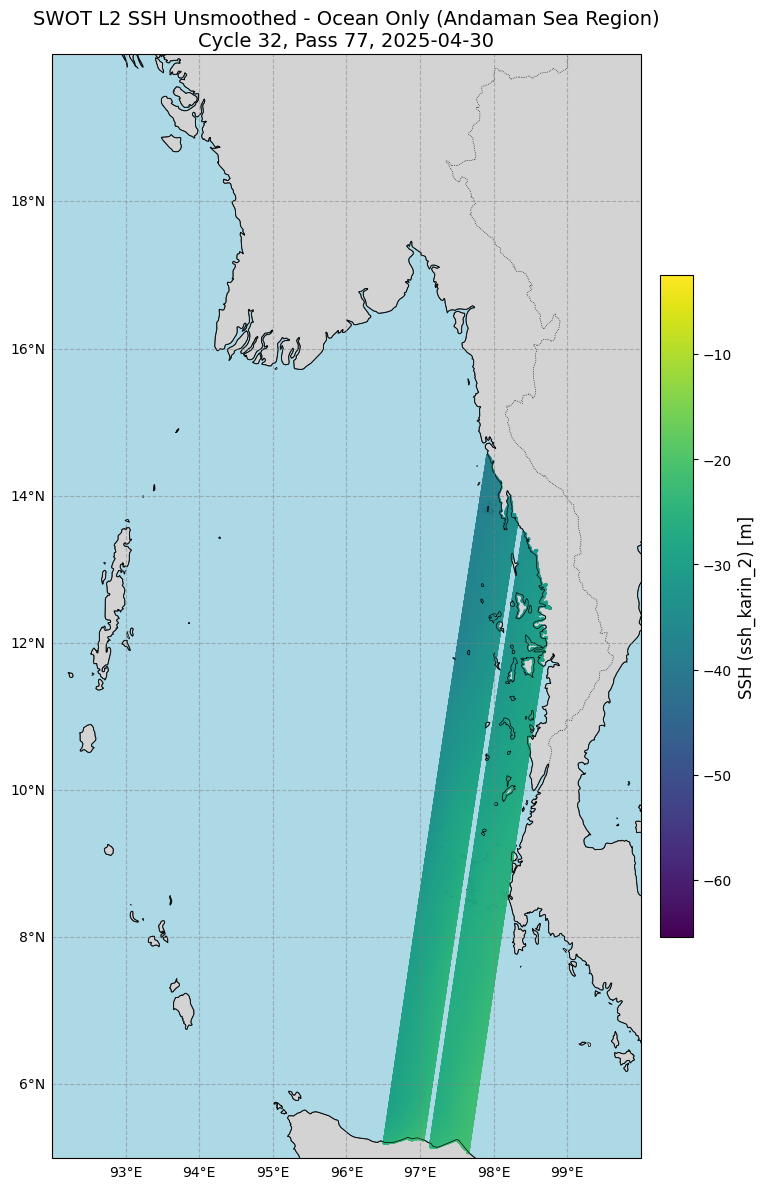

In [83]:
# Plot raw SSH data - OCEAN ONLY for Andaman Sea Region
print("Plotting raw SSH data - Ocean Only (Andaman Sea Region)...")

# Define Andaman Sea region bounds
# Latitude: ~5°N to ~20°N, Longitude: ~92°E to ~100°E
ANDAMAN_LAT_MIN, ANDAMAN_LAT_MAX = 5.0, 20.0
ANDAMAN_LON_MIN, ANDAMAN_LON_MAX = 92.0, 100.0

# Create figure
fig, ax = plt.subplots(figsize=(10, 12), subplot_kw=dict(projection=ccrs.PlateCarree()))

# Add map features
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)

# # Collect data for plotting
has_data = True

# Plot both swaths - OCEAN ONLY
for swath_name, ds_swath in [('left', ds_left), ('right', ds_right)]:
    lat = ds_swath.coords['latitude'].values
    lon = ds_swath.coords['longitude'].values
    ssh = ds_swath['ssh_karin_2'].values
    

    #masking for ocean region and vaild data 

    # Get surface classification flag (0 = open ocean)
    if 'ancillary_surface_classification_flag' in ds_swath:
        ocean_mask = (ds_swath['ancillary_surface_classification_flag'].values == 0)  
    else:
        ocean_mask = np.ones_like(ssh, dtype=bool)
    
    # Create regional mask for Andaman Sea
    region_mask = (lat >= ANDAMAN_LAT_MIN) & (lat <= ANDAMAN_LAT_MAX) & \
                  (lon >= ANDAMAN_LON_MIN) & (lon <= ANDAMAN_LON_MAX)
    
    valid_mask = ~np.isnan(lon + lat + ssh)
    
    # Combine masks: valid data + ocean only + regional
    
    combined_mask = valid_mask & ocean_mask & region_mask
    
    # Check if there's data in this region
    if np.sum(combined_mask) > 0:
        has_data = True
        # Plot SSH data - ocean only
        cax = ax.scatter(lon[combined_mask], lat[combined_mask], 
                         c=ssh[combined_mask], s=0.5, 
                         cmap='viridis', 
                         transform=ccrs.PlateCarree())
        print(f"  {swath_name.capitalize()} swath: {np.sum(combined_mask)} ocean data points in region")

if has_data:
    # Add colorbar
    cbar = plt.colorbar(cax, ax=ax, shrink=0.6, pad=0.02)
    cbar.set_label('SSH (ssh_karin_2) [m]', fontsize=12)

    # Add gridlines
    gl = ax.gridlines(draw_labels=True, color='gray', alpha=0.5, linestyle='--')
    gl.right_labels = False
    gl.top_labels = False

    # Set extent to Andaman Sea region
    ax.set_extent([ANDAMAN_LON_MIN, ANDAMAN_LON_MAX, ANDAMAN_LAT_MIN, ANDAMAN_LAT_MAX], crs=ccrs.PlateCarree())

    # Title
    ax.set_title(f'SWOT L2 SSH Unsmoothed - Ocean Only (Andaman Sea Region)\n'
                 f'Cycle {ds_root.attrs.get("cycle_number")}, Pass {ds_root.attrs.get("pass_number")}, '
                 f'{ds_root.attrs.get("time_coverage_start", "")[:10]}', fontsize=14)

    plt.tight_layout()
    plt.show()
else:
    plt.close()
    print("\n⚠️ No ocean data found in Andaman Sea region for this pass!")
    print(f"   Region bounds: Lat {ANDAMAN_LAT_MIN}°-{ANDAMAN_LAT_MAX}°N, Lon {ANDAMAN_LON_MIN}°-{ANDAMAN_LON_MAX}°E")
    print("\n   This pass may not cover this region. Checking data coverage...")

In [84]:
# ============================================================================
# CROSS-SWATH BIAS CORRECTION FUNCTIONS
# ============================================================================
# These functions are adapted from swot_ssh_utils for removing systematic 
# cross-track biases in SWOT SSH data

from scipy.optimize import leastsq

def distance_between_points(lon0, lons, lat0, lats):
    """
    Calculate the distance between two points on Earth's surface using haversine formula.
    Returns distance in meters.
    """
    degrees_to_radians = np.pi/180.0
    phi1 = lat0 * degrees_to_radians
    phi2 = lats * degrees_to_radians
    dphi = phi1 - phi2
    theta1 = lon0 * degrees_to_radians
    theta2 = lons * degrees_to_radians
    dtheta = theta1 - theta2
    
    co = np.sqrt(np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dtheta/2.0)**2)
    arc = 2 * np.arcsin(co)
    dist = arc * 6371.0e3  # Earth radius in meters
    return dist

def calculate_cross_track_distance(lat, lon):
    """
    Calculate cross-track distance from the nadir (center) of the swath.
    Returns distance in meters for each pixel.
    """
    # Get nadir position (center of swath)
    nadir_lon = np.nanmean(lon, axis=1, keepdims=True)
    nadir_lat = np.nanmean(lat, axis=1, keepdims=True)
    
    # Calculate distance from nadir
    cross_track_dist = distance_between_points(nadir_lon, lon, nadir_lat, lat)
    
    # Assign sign based on position relative to nadir
    num_pixels = lon.shape[1]
    center_idx = num_pixels // 2
    
    # Pixels to the left of center get negative distance
    cross_track_dist[:, :center_idx] = -cross_track_dist[:, :center_idx]
    
    return cross_track_dist

def fit_bias(ssh, cross_track_distance, tol=1e-4, order=2, iter_max=20,
             remove_along_track_polynomial=False, check_bad_point_threshold=0.6):
    """
    Fit and remove cross-swath bias from SSH data.
    
    Parameters:
    -----------
    ssh : numpy.ndarray
        2D array of SSH data (num_lines x num_pixels)
    cross_track_distance : numpy.ndarray
        2D array of cross-track distances in meters
    order : int
        Polynomial order for bias fitting (2 or 3)
    iter_max : int
        Maximum iterations for bias removal
    
    Returns:
    --------
    numpy.ndarray
        Bias-corrected SSH anomaly
    """
    
    def err(cc, x0, p, order):
        if order == 2:
            a, b, c = cc 
            return p - (a + b*x0 + c*x0**2)
        if order == 3:
            a, b, c, d = cc
            return p - (a + b*x0 + c*x0**2 + d*x0**3)
    
    def get_anomaly(ssha, distance, order):
        msk = np.isfinite(ssha.flatten())
        if msk.sum() < ssha.size * check_bad_point_threshold:
            return np.zeros_like(ssha) * np.nan
        x = distance
        xf = x.flatten()[msk]
        pf = ssha.flatten()[msk]
        
        cc = [0.0] * (order + 1)
        coef = leastsq(err, cc, args=(xf, pf, order))[0]
        anomaly = err(coef, x, ssha, order)
        return anomaly
    
    # Get mean cross-track distance per pixel
    cdis = np.nanmean(cross_track_distance, axis=0) / 1e3  # Convert to km
    
    # Masks for left and right sides of swath
    m1 = cdis > 0  # Right side
    m2 = cdis < 0  # Left side
    
    # Initialize anomaly array
    ano = np.where(np.isfinite(ssh), np.zeros(ssh.shape), np.nan)
    
    # First pass: fit bias for each side
    ano[:, m1] = get_anomaly(ssh[:, m1], cross_track_distance[:, m1], order)
    ano[:, m2] = get_anomaly(ssh[:, m2], cross_track_distance[:, m2], order)
    
    # Iterative refinement (first half without outlier removal)
    for i in range(iter_max // 2):
        ano[:, m1] = get_anomaly(ano[:, m1], cross_track_distance[:, m1], order)
        ano[:, m2] = get_anomaly(ano[:, m2], cross_track_distance[:, m2], order)
    
    # Second half with outlier removal
    for i in range(iter_max // 2):
        ano[:, m1] = get_anomaly(ano[:, m1], cross_track_distance[:, m1], order)
        ano[:, m2] = get_anomaly(ano[:, m2], cross_track_distance[:, m2], order)
        ano = np.where(np.abs(ano - np.nanmean(ano)) > 5 * np.nanstd(ano), np.nan, ano)
    
    # Preserve original NaN mask
    ano = np.where(np.isnan(ssh), np.nan, ano)
    
    return ano

print("✓ Cross-swath bias correction functions defined successfully!")

✓ Cross-swath bias correction functions defined successfully!


In [85]:
# ============================================================================
# CROSS-SWATH BIAS REMOVAL (For Older Product Versions - PGC0/PIC0/PIA1/PJB0)
# ============================================================================
# Based on SWOT Product Description Document (Revision C, Feb 2025):
#
# For OLDER files (pre-Nov 2024): ssha_karin_2 is NOT available
# Must compute SSHA manually, then apply crossover correction
#
# FORMULA (from documentation):
# SSHA = SSH - MSS - solid_earth_tide - ocean_tide - load_tide - 
#        internal_tide - pole_tide - DAC
#
# NOTE: In ssh_karin_2, tides and DAC are ALREADY APPLIED, so:
# SSHA = ssh_karin_2 - mean_sea_surface_cnescls
#
# CRITICAL: Crossover Correction
# The crossover correction (height_cor_xover) removes METER-SCALE cross-track
# tilts caused by residual roll/phase errors. This is reported but NOT applied
# to LR SSH products - users MUST apply it themselves:
#
# Corrected_SSHA = SSHA + height_cor_xover  (ADD, not subtract!)
# ============================================================================

print("=" * 80)
print("CROSS-SWATH BIAS REMOVAL")
print("For Older Product Version (pre-November 2024)")
print("=" * 80)

corrected_data = {}

for swath_name, ds_swath in [('left', ds_left), ('right', ds_right)]:
    print(f"\n{'='*60}")
    print(f"Processing {swath_name.upper()} swath")
    print(f"{'='*60}")

    # ========================================================================
    # STEP 1: Extract coordinates
    # ========================================================================
    lat = ds_swath['latitude'].values
    lon = ds_swath['longitude'].values
    
    # ========================================================================
    # STEP 2: Get SSH and MSS, filter fill values
    # ========================================================================
    ssh_raw = ds_swath['ssh_karin_2'].values.copy()
    mss_raw = ds_swath['mean_sea_surface_cnescls'].values.copy()
    
    FILL_THRESHOLD = 1e10
    
    # Filter fill values
    ssh = np.where(np.abs(ssh_raw) > FILL_THRESHOLD, np.nan, ssh_raw)
    mss = np.where(np.abs(mss_raw) > FILL_THRESHOLD, np.nan, mss_raw)
    
    # Physical bounds
    ssh = np.where(np.abs(ssh) > 150, np.nan, ssh)
    mss = np.where(np.abs(mss) > 150, np.nan, mss)
    
    print(f"  SSH valid points: {np.sum(~np.isnan(ssh))}")
    print(f"  MSS valid points: {np.sum(~np.isnan(mss))}")
    
    # ========================================================================
    # STEP 3: Compute SSHA
    # For ssh_karin_2, tides and DAC are already applied, so:
    # SSHA = ssh_karin_2 - MSS
    # ========================================================================
    ssha = ssh - mss
    
    # Filter unrealistic SSHA (should be within ±5m for ocean)
    ssha = np.where(np.abs(ssha) > 5, np.nan, ssha)
    print(f"  SSHA computed: {np.sum(~np.isnan(ssha))} valid points")
    
    # ========================================================================
    # STEP 4: Apply Crossover Correction (CRITICAL!)
    # ========================================================================
    # The crossover correction removes meter-scale cross-track tilts caused by
    # residual roll/phase errors. It is REPORTED but NOT APPLIED in L2_LR_SSH.
    # Users MUST apply it: Corrected = Reported + height_cor_xover
    # ========================================================================
    xover_applied = False
    if 'height_cor_xover' in ds_swath:
        xover_raw = ds_swath['height_cor_xover'].values.copy()
        xover = np.where(np.abs(xover_raw) > FILL_THRESHOLD, np.nan, xover_raw)
        
        # Check if we have valid crossover corrections
        valid_xover = np.sum(~np.isnan(xover))
        if valid_xover > 0:
            # Apply correction: ADD to SSHA (not subtract!)
            ssha_xover = ssha + xover
            xover_applied = True
            print(f"  ✓ Applied height_cor_xover: {valid_xover} valid corrections")
            print(f"    Xover range: {np.nanmin(xover):.4f} to {np.nanmax(xover):.4f} m")
            print(f"    Xover mean: {np.nanmean(xover):.4f} m")
        else:
            ssha_xover = ssha.copy()
            print(f"  ⚠️ height_cor_xover has no valid data")
    else:
        ssha_xover = ssha.copy()
        print(f"  ⚠️ height_cor_xover not available")
    
    # Use crossover-corrected SSHA for further processing
    ssha = ssha_xover
    
    # ========================================================================
    # STEP 5: Apply ocean mask
    # ========================================================================
    if 'ancillary_surface_classification_flag' in ds_swath:
        ocean_mask = ds_swath['ancillary_surface_classification_flag'].values == 0
        ssha = np.where(ocean_mask, ssha, np.nan)
        print(f"  ✓ Applied ocean mask: {np.sum(~np.isnan(ssha))} ocean points")
    
    # ========================================================================
    # STEP 6: Calculate cross_track_distance
    # ========================================================================
    cross_track_dist = calculate_cross_track_distance(lat, lon)
    print(f"  ✓ Calculated cross_track_distance")
    print(f"    Range: {np.nanmin(cross_track_dist)/1000:.1f} to {np.nanmax(cross_track_dist)/1000:.1f} km")
    
    print(f"\n  --- Data Statistics (After All Corrections) ---")
    print(f"  SSHA range: {np.nanmin(ssha):.4f} to {np.nanmax(ssha):.4f} m")
    print(f"  SSHA mean: {np.nanmean(ssha):.4f} m, std: {np.nanstd(ssha):.4f} m")
    
    # ========================================================================
    # Along-Track Mean Subtraction (Cross-Swath Bias Removal)
    # ========================================================================
    print(f"\n  --- Cross-Swath Bias Removal: Along-Track Mean ---")
    
    lat_col = lat[:, lat.shape[1] // 2]
    lat_col = np.where(np.isnan(lat_col), -999, lat_col)
    lat_mask = (lat_col > ANDAMAN_LAT_MIN) & (lat_col < ANDAMAN_LAT_MAX)
    
    if np.sum(lat_mask) > 100:
        along_track_mean = np.nanmean(ssha[lat_mask, :], axis=0, keepdims=True)
        ssha_corrected = ssha - along_track_mean
        print(f"  ✓ Applied latitude-bounded mean ({np.sum(lat_mask)} lines)")
    else:
        along_track_mean = np.nanmean(ssha, axis=0, keepdims=True)
        ssha_corrected = ssha - along_track_mean
        print(f"  ⚠️ Using full-array mean")
    
    print(f"  Corrected SSHA - Mean: {np.nanmean(ssha_corrected):.4f} m, Std: {np.nanstd(ssha_corrected):.4f} m")
    
    # ========================================================================
    # Store results
    # ========================================================================
    corrected_data[swath_name] = {
        'lat': lat,
        'lon': lon,
        'ssha_original': ssha,
        'ssha_corrected': ssha_corrected,
        'bias_removed': along_track_mean,
        'cross_track_dist': cross_track_dist,
        'xover_applied': xover_applied
    }

print("\n" + "=" * 80)
print("✓ Cross-swath bias removal completed!")
print("=" * 80)
print("\nProcessing Pipeline:")
print("  1. Filtered fill values (>1e10)")
print("  2. Computed SSHA = ssh_karin_2 - mean_sea_surface_cnescls")
print("  3. Applied height_cor_xover (crossover calibration)")
print("  4. Applied ocean mask (flag==0)")
print("  5. Calculated cross_track_distance")
print("  6. Removed cross-swath bias (along-track mean subtraction)")
print("\n📚 PHYSICS NOTE:")
print("  The crossover correction removes meter-scale cross-track tilts caused")
print("  by residual roll/phase errors in the KaRIn instrument. These errors")
print("  are estimated by comparing ascending/descending passes at crossover")
print("  points where the same ocean area is observed from different geometries.")

CROSS-SWATH BIAS REMOVAL
For Older Product Version (pre-November 2024)

Processing LEFT swath
  SSH valid points: 11070696
  MSS valid points: 19422452
  SSHA computed: 10642905 valid points
  ⚠️ height_cor_xover not available
  ✓ Applied ocean mask: 10527023 ocean points
  ✓ Calculated cross_track_distance
    Range: -30.2 to 30.1 km

  --- Data Statistics (After All Corrections) ---
  SSHA range: -4.9992 to 4.9942 m
  SSHA mean: -0.7332 m, std: 0.5464 m

  --- Cross-Swath Bias Removal: Along-Track Mean ---
  ✓ Applied latitude-bounded mean (7120 lines)
  Corrected SSHA - Mean: -0.9404 m, Std: 0.4002 m

Processing RIGHT swath
  SSH valid points: 11073313
  MSS valid points: 19422224
  SSHA computed: 10482655 valid points
  ⚠️ height_cor_xover not available
  ✓ Applied ocean mask: 10237264 ocean points
  ✓ Calculated cross_track_distance
    Range: -30.2 to 30.1 km

  --- Data Statistics (After All Corrections) ---
  SSHA range: -4.9895 to 4.9999 m
  SSHA mean: 0.6262 m, std: 0.5017 m


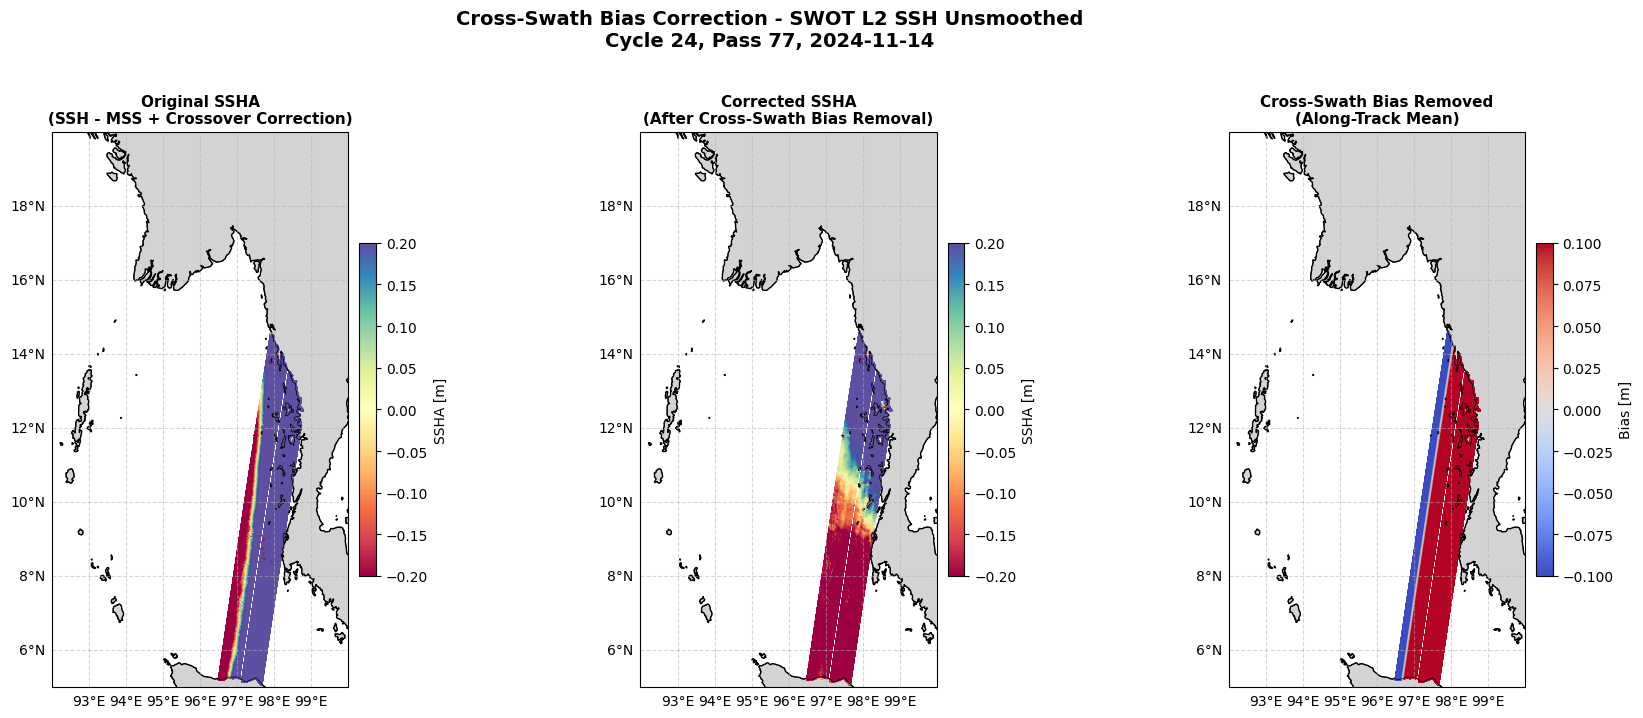


✓ Visualization complete!
  Left: Original SSHA (with crossover correction applied)
  Center: Corrected SSHA (cross-swath bias removed)
  Right: Bias that was removed (along-track mean per pixel column)


In [86]:
# ============================================================================
# VISUALIZE: Cross-Swath Bias Correction (Andaman Sea Region)
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 7), 
                          subplot_kw=dict(projection=ccrs.PlateCarree()))

# Color scales for SSHA (±0.2m as in official toolkit)
vmin_ssha, vmax_ssha = -0.20, 0.20
vmin_bias, vmax_bias = -0.10, 0.10

# ============================================================================
# Panel 1: Original SSHA
# ============================================================================
ax = axes[0]
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

for swath_name in ['left', 'right']:
    data = corrected_data[swath_name]
    lat, lon = data['lat'], data['lon']
    ssha = data['ssha_original']
    
    region_mask = (lat >= ANDAMAN_LAT_MIN) & (lat <= ANDAMAN_LAT_MAX) & \
                  (lon >= ANDAMAN_LON_MIN) & (lon <= ANDAMAN_LON_MAX)
    valid_mask = ~np.isnan(ssha)
    combined_mask = valid_mask & region_mask
    
    if np.sum(combined_mask) > 0:
        sc = ax.scatter(lon[combined_mask], lat[combined_mask], 
                        c=ssha[combined_mask], s=0.5, cmap='Spectral',
                        vmin=vmin_ssha, vmax=vmax_ssha, transform=ccrs.PlateCarree())

ax.set_extent([ANDAMAN_LON_MIN, ANDAMAN_LON_MAX, ANDAMAN_LAT_MIN, ANDAMAN_LAT_MAX])
ax.set_title('Original SSHA\n(SSH - MSS + Crossover Correction)', fontsize=11, fontweight='bold')
gl = ax.gridlines(draw_labels=True, alpha=0.5, linestyle='--')
gl.right_labels = gl.top_labels = False
cbar = plt.colorbar(sc, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label('SSHA [m]')

# ============================================================================
# Panel 2: Corrected SSHA (After Cross-Swath Bias Removal)
# ============================================================================
ax = axes[1]
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

for swath_name in ['left', 'right']:
    data = corrected_data[swath_name]
    lat, lon = data['lat'], data['lon']
    ssha_corr = data['ssha_corrected']
    
    region_mask = (lat >= ANDAMAN_LAT_MIN) & (lat <= ANDAMAN_LAT_MAX) & \
                  (lon >= ANDAMAN_LON_MIN) & (lon <= ANDAMAN_LON_MAX)
    valid_mask = ~np.isnan(ssha_corr)
    combined_mask = valid_mask & region_mask
    
    if np.sum(combined_mask) > 0:
        sc = ax.scatter(lon[combined_mask], lat[combined_mask], 
                        c=ssha_corr[combined_mask], s=0.5, cmap='Spectral',
                        vmin=vmin_ssha, vmax=vmax_ssha, transform=ccrs.PlateCarree())

ax.set_extent([ANDAMAN_LON_MIN, ANDAMAN_LON_MAX, ANDAMAN_LAT_MIN, ANDAMAN_LAT_MAX])
ax.set_title('Corrected SSHA\n(After Cross-Swath Bias Removal)', fontsize=11, fontweight='bold')
gl = ax.gridlines(draw_labels=True, alpha=0.5, linestyle='--')
gl.right_labels = gl.top_labels = False
cbar = plt.colorbar(sc, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label('SSHA [m]')

# ============================================================================
# Panel 3: Bias Removed
# ============================================================================
ax = axes[2]
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

for swath_name in ['left', 'right']:
    data = corrected_data[swath_name]
    lat, lon = data['lat'], data['lon']
    bias = data['bias_removed']
    # Broadcast bias to full array shape
    bias_full = np.broadcast_to(bias, data['ssha_original'].shape)
    
    region_mask = (lat >= ANDAMAN_LAT_MIN) & (lat <= ANDAMAN_LAT_MAX) & \
                  (lon >= ANDAMAN_LON_MIN) & (lon <= ANDAMAN_LON_MAX)
    valid_mask = ~np.isnan(data['ssha_original'])
    combined_mask = valid_mask & region_mask
    
    if np.sum(combined_mask) > 0:
        sc = ax.scatter(lon[combined_mask], lat[combined_mask], 
                        c=bias_full[combined_mask], s=0.5, cmap='coolwarm',
                        vmin=vmin_bias, vmax=vmax_bias, transform=ccrs.PlateCarree())

ax.set_extent([ANDAMAN_LON_MIN, ANDAMAN_LON_MAX, ANDAMAN_LAT_MIN, ANDAMAN_LAT_MAX])
ax.set_title('Cross-Swath Bias Removed\n(Along-Track Mean)', fontsize=11, fontweight='bold')
gl = ax.gridlines(draw_labels=True, alpha=0.5, linestyle='--')
gl.right_labels = gl.top_labels = False
cbar = plt.colorbar(sc, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label('Bias [m]')

# Use the file index that was loaded (index 0)
file_idx = 0
plt.suptitle(f'Cross-Swath Bias Correction - SWOT L2 SSH Unsmoothed\n'
             f'Cycle {selected_files[file_idx]["cycle"]}, Pass {selected_files[file_idx]["pass_number"]}, '
             f'{selected_files[file_idx]["start_datetime"].strftime("%Y-%m-%d")}', 
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

print("\n✓ Visualization complete!")
print("  Left: Original SSHA (with crossover correction applied)")
print("  Center: Corrected SSHA (cross-swath bias removed)")
print("  Right: Bias that was removed (along-track mean per pixel column)")

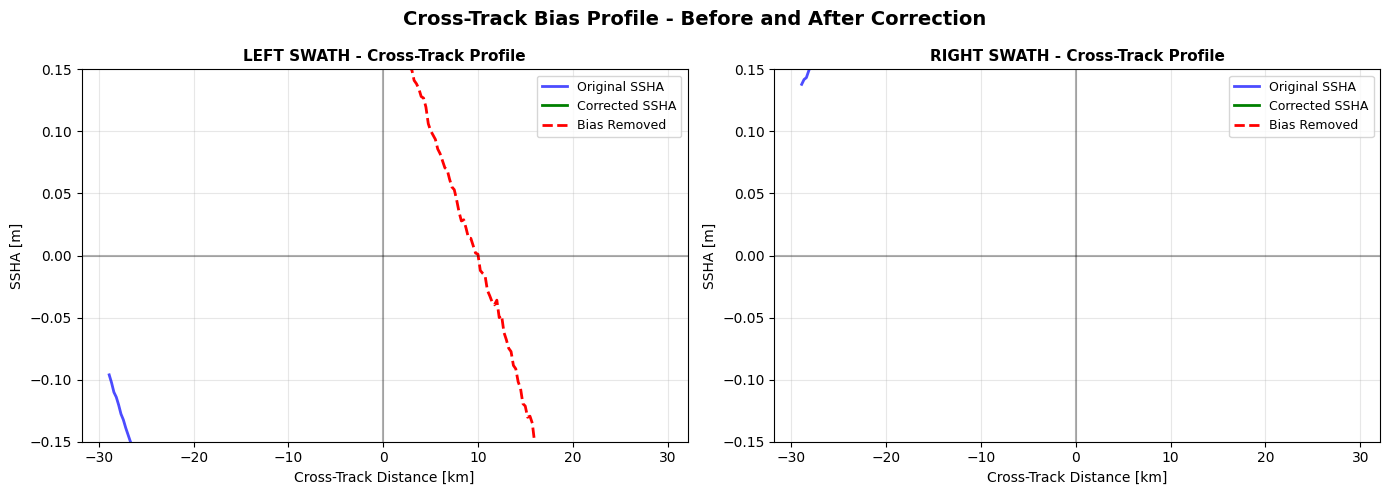


SUMMARY: CROSS-TRACK BIAS STATISTICS

LEFT SWATH:
  Original SSHA std:  54.64 cm
  Corrected SSHA std: 40.02 cm
  Bias removed std:   35.49 cm
  Crossover applied:  No

RIGHT SWATH:
  Original SSHA std:  50.17 cm
  Corrected SSHA std: 41.32 cm
  Bias removed std:   26.81 cm
  Crossover applied:  No


In [87]:
# ============================================================================
# CROSS-TRACK PROFILE: Before and After Bias Removal
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, swath_name in enumerate(['left', 'right']):
    data = corrected_data[swath_name]
    
    # Get cross-track distance in km
    ctd = data['cross_track_dist'] / 1e3
    ssha_orig = data['ssha_original']
    ssha_corr = data['ssha_corrected']
    
    # Calculate mean profiles
    ctd_mean = np.nanmean(ctd, axis=0)
    ssha_orig_mean = np.nanmean(ssha_orig, axis=0)
    ssha_corr_mean = np.nanmean(ssha_corr, axis=0)
    bias_mean = data['bias_removed'].flatten()
    
    ax = axes[idx]
    ax.plot(ctd_mean, ssha_orig_mean, 'b-', label='Original SSHA', linewidth=2, alpha=0.7)
    ax.plot(ctd_mean, ssha_corr_mean, 'g-', label='Corrected SSHA', linewidth=2)
    ax.plot(ctd_mean, bias_mean, 'r--', label='Bias Removed', linewidth=2)
    
    ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    ax.axvline(x=0, color='k', linestyle='-', alpha=0.3)
    ax.set_xlabel('Cross-Track Distance [km]', fontsize=10)
    ax.set_ylabel('SSHA [m]', fontsize=10)
    ax.set_title(f'{swath_name.upper()} SWATH - Cross-Track Profile', fontsize=11, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.15, 0.15)

plt.suptitle('Cross-Track Bias Profile - Before and After Correction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "=" * 80)
print("SUMMARY: CROSS-TRACK BIAS STATISTICS")
print("=" * 80)
for swath_name in ['left', 'right']:
    data = corrected_data[swath_name]
    print(f"\n{swath_name.upper()} SWATH:")
    print(f"  Original SSHA std:  {np.nanstd(data['ssha_original'])*100:.2f} cm")
    print(f"  Corrected SSHA std: {np.nanstd(data['ssha_corrected'])*100:.2f} cm")
    print(f"  Bias removed std:   {np.nanstd(data['bias_removed'])*100:.2f} cm")
    print(f"  Crossover applied:  {'Yes' if data['xover_applied'] else 'No'}")